<a href="https://colab.research.google.com/github/oihika/JABALPUR-AI-Driven-Framework-for-Techno-Economic-Optimization-of-Hybrid-Solar-PV-BESS-Systems/blob/main/code_with_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# JABALPUR INTEGRATED PV-BESS RESEARCH FRAMEWORK
# Google Colab
# ============================================================

!pip -q install pvlib xgboost scikit-learn deap openpyxl

import os
import json
import math
import warnings
import random
import requests

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pvlib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)

print("Environment ready.")
print("pvlib version:", pvlib.__version__)

# ============================================================
# RESEARCH CONFIGURATION
# ============================================================

CONFIG = {
    "location": "Jabalpur, Madhya Pradesh, India",
    "latitude": 23.1815,
    "longitude": 79.9864,
    "timezone": "Asia/Kolkata",
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "pv_min_kw": 5,
    "pv_max_kw": 40,
    "bess_min_kwh": 20,
    "bess_max_kwh": 200,
    "battery_charge_efficiency": 0.95,
    "battery_discharge_efficiency": 0.95,
    "soc_min": 0.10,
    "soc_max": 0.95,
    "initial_soc": 0.50,
    "max_charge_c_rate": 0.5,
    "max_discharge_c_rate": 0.5,
    "calendar_degradation_yearly": 0.015,
    "cycle_degradation_per_1000_cycles": 0.08,
    "end_of_life_soh": 0.80,
    "pv_capex_inr_per_kw": 50000,
    "bess_capex_inr_per_kwh": 12000,
    "battery_replacement_cost_fraction": 0.70,
    "annual_om_fraction": 0.015,
    "grid_import_tariff_inr_per_kwh": 8.0,
    "grid_export_tariff_inr_per_kwh": 3.0,
    "discount_rate": 0.08,
    "project_lifetime_years": 15,
    "forecast_horizon_hours": 1,
    "monte_carlo_iterations": 100,
    "population_size": 40,
    "generations": 20,
    "random_seed": 42
}

print(json.dumps(CONFIG, indent=4))

# ============================================================
# NASA POWER DATA RETRIEVAL
# JABALPUR
# ============================================================

LATITUDE = CONFIG["latitude"]
LONGITUDE = CONFIG["longitude"]
START_DATE = CONFIG["start_date"].replace("-", "")
END_DATE = CONFIG["end_date"].replace("-", "")

parameters = ",".join([
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_SW_DIFF",
    "T2M",
    "WS10M",
    "RH2M"
])

url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    f"?parameters={parameters}"
    f"&community=RE"
    f"&longitude={LONGITUDE}"
    f"&latitude={LATITUDE}"
    f"&start={START_DATE}"
    f"&end={END_DATE}"
    f"&format=JSON"
    f"&time-standard=UTC"
)

print("Requesting NASA POWER data with url:", url)
response = requests.get(url, timeout=180)
response.raise_for_status()
power_json = response.json()
print("NASA POWER request successful.")

# ============================================================
# NASA POWER → DATAFRAME
# ============================================================

power_data = power_json["properties"]["parameter"]
resource = pd.DataFrame(power_data)
resource.index = pd.to_datetime(resource.index, format="%Y%m%d%H", utc=True)
resource.index = resource.index.tz_convert(CONFIG["timezone"])
resource.index.name = "datetime"
resource["data_source"] = "NASA POWER"

numeric_columns = [
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_SW_DIFF",
    "T2M",
    "WS10M",
    "RH2M"
]

for col in numeric_columns:
    resource[col] = pd.to_numeric(resource[col], errors="coerce")

# ============================================================
# DATA QUALITY CONTROL
# ============================================================

irradiance_columns = ["ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_SW_DNI", "ALLSKY_SFC_SW_DIFF"]
for col in irradiance_columns:
    resource[col] = resource[col].clip(lower=0)

resource[numeric_columns] = resource[numeric_columns].interpolate(limit=3)
resource[numeric_columns] = resource[numeric_columns].ffill().bfill()

# ============================================================
# TEMPORAL FEATURES
# ============================================================

resource["hour"] = resource.index.hour
resource["day_of_year"] = resource.index.dayofyear
resource["month"] = resource.index.month
resource["day_of_week"] = resource.index.dayofweek

resource["sin_hour"] = np.sin(2 * np.pi * resource["hour"] / 24)
resource["cos_hour"] = np.cos(2 * np.pi * resource["hour"] / 24)
resource["sin_day"] = np.sin(2 * np.pi * resource["day_of_year"] / 365)
resource["cos_day"] = np.cos(2 * np.pi * resource["day_of_year"] / 365)

# ============================================================
# PV PERFORMANCE MODEL
# ============================================================

def add_pv_features(df, pv_capacity_kw=10, tilt=23.18, azimuth=180, albedo=0.20):
    out = df.copy()
    solar_position = pvlib.solarposition.get_solarposition(
        time=out.index, latitude=CONFIG["latitude"], longitude=CONFIG["longitude"]
    )
    out["solar_zenith"] = solar_position["zenith"]
    out["solar_azimuth"] = solar_position["azimuth"]

    ghi = out["ALLSKY_SFC_SW_DWN"].clip(lower=0)
    dni = out["ALLSKY_SFC_SW_DNI"].clip(lower=0)
    dhi = out["ALLSKY_SFC_SW_DIFF"].clip(lower=0)
    dni_extra = pvlib.irradiance.get_extra_radiation(out.index)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        solar_zenith=out["solar_zenith"],
        solar_azimuth=out["solar_azimuth"],
        dni=dni,
        ghi=ghi,
        dhi=dhi,
        dni_extra=dni_extra,
        model="haydavies",
        albedo=albedo
    )

    out["poa_global"] = poa["poa_global"]
    out["poa_direct"] = poa["poa_direct"]
    out["poa_diffuse"] = poa["poa_diffuse"]
    out["temp_cell"] = out["T2M"] + 20.0 * out["poa_global"] / 800.0

    pdc0 = pv_capacity_kw * 1000
    out["pv_dc_w"] = pvlib.pvsystem.pvwatts_dc(
        effective_irradiance=out["poa_global"], temp_cell=out["temp_cell"], pdc0=pdc0, gamma_pdc=-0.004
    )
    out["pv_dc_kw"] = out["pv_dc_w"] / 1000
    out["pv_ac_w"] = pvlib.inverter.pvwatts(pdc=out["pv_dc_w"], pdc0=pdc0)
    out["pv_ac_kw"] = out["pv_ac_w"] / 1000
    out["pv_energy_kwh"] = out["pv_ac_kw"].clip(lower=0)
    return out

base = add_pv_features(resource, pv_capacity_kw=10)

# ============================================================
# SYNTHETIC RESIDENTIAL LOAD
# ============================================================

def create_synthetic_load(index):
    hour = index.hour
    month = index.month
    load = np.full(len(index), 0.45)
    load += np.where((hour >= 6) & (hour <= 9), 0.35, 0)
    load += np.where((hour >= 18) & (hour <= 23), 0.65, 0)
    load += np.where((hour >= 11) & (hour <= 15), 0.15, 0)
    load += np.where(month.isin([4,5,6]), 0.20, 0)
    noise = np.random.normal(0, 0.05, len(index))
    load += noise
    return np.clip(load, 0.15, None)

base["load_kw"] = create_synthetic_load(base.index)
base["load_data_source"] = "Synthetic residential profile"

# ============================================================
# FORECASTING DATASET
# ============================================================

forecast_df = base.copy()
forecast_df["ghi_lag1"] = forecast_df["ALLSKY_SFC_SW_DWN"].shift(1)
forecast_df["ghi_lag2"] = forecast_df["ALLSKY_SFC_SW_DWN"].shift(2)
forecast_df["temp_lag1"] = forecast_df["T2M"].shift(1)
forecast_df["pv_lag1"] = forecast_df["pv_ac_kw"].shift(1)
forecast_df["load_lag1"] = forecast_df["load_kw"].shift(1)
forecast_df["load_lag24"] = forecast_df["load_kw"].shift(24)
forecast_df = forecast_df.dropna()

features = [
    "ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_SW_DNI", "ALLSKY_SFC_SW_DIFF", "T2M", "WS10M", "RH2M",
    "hour", "day_of_year", "sin_hour", "cos_hour", "sin_day", "cos_day",
    "ghi_lag1", "ghi_lag2", "temp_lag1", "pv_lag1", "load_lag1", "load_lag24"
]
target = "pv_ac_kw"

X = forecast_df[features]
y = forecast_df[target]

n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# ============================================================
# RANDOM FOREST FORECASTER
# ============================================================

rf_model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ============================================================
# XGBOOST FORECASTER
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# ============================================================
# LSTM FORECASTER (Robust Implementation without Leakage)
# ============================================================

lstm_features = ["ALLSKY_SFC_SW_DWN", "T2M", "WS10M", "RH2M", "hour", "day_of_year", "pv_ac_kw"]
lstm_data = forecast_df[lstm_features].copy().values

# Correct validation flow split
lstm_n = len(lstm_data)
seq_len = 24

train_idx_end = int(lstm_n * 0.70)
val_idx_end = int(lstm_n * 0.85)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Extract and scale target separately to avoid inversion issues
target_idx = lstm_features.index("pv_ac_kw")
scaled_features_train = scaler_features.fit_transform(lstm_data[:train_idx_end, :target_idx])
scaled_target_train = scaler_target.fit_transform(lstm_data[:train_idx_end, target_idx].reshape(-1, 1))

# Fit on whole but scale partitions separately using the fitted metrics
scaled_features_all = scaler_features.transform(lstm_data[:, :target_idx])
scaled_target_all = scaler_target.transform(lstm_data[:, target_idx].reshape(-1, 1))
scaled_all = np.hstack([scaled_features_all, scaled_target_all])

def create_sequences(data, target_col_idx, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(data)):
        X_seq.append(data[i-seq_length:i])
        y_seq.append(data[i, target_col_idx])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(scaled_all, target_idx, seq_len)

# Ensure sequence splits align properly
seq_train_split = train_idx_end - seq_len
seq_val_split = val_idx_end - seq_len

X_lstm_train, y_lstm_train = X_seq[:seq_train_split], y_seq[:seq_train_split]
X_lstm_val, y_lstm_val = X_seq[seq_train_split:seq_val_split], y_seq[seq_train_split:seq_val_split]
X_lstm_test, y_lstm_test = X_seq[seq_val_split:], y_seq[seq_val_split:]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_lstm_train, y_lstm_train, validation_data=(X_lstm_val, y_lstm_val),
    epochs=10, batch_size=64, callbacks=[early_stop], verbose=0
)

lstm_scaled_pred = lstm_model.predict(X_lstm_test, verbose=0).flatten()
lstm_pred = scaler_target.inverse_transform(lstm_scaled_pred.reshape(-1, 1)).flatten()
lstm_actual = scaler_target.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()

# ============================================================
# PERFORMANCE METRICS & SYSTEM RE-ALIGNMENT
# ============================================================

def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    nonzero = np.abs(actual) > 0.05
    mape = np.mean(np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])) * 100 if nonzero.sum() > 0 else np.nan
    return rmse, mae, mape

rf_metrics = calculate_metrics(y_test.values, rf_pred)
xgb_metrics = calculate_metrics(y_test.values, xgb_pred)
lstm_metrics = calculate_metrics(lstm_actual, lstm_pred)

print("=== PREDICTION PERFORMANCE SUMMARY ===")
print(f"Random Forest - RMSE: {rf_metrics[0]:.4f}, MAE: {rf_metrics[1]:.4f}")
print(f"XGBoost       - RMSE: {xgb_metrics[0]:.4f}, MAE: {xgb_metrics[1]:.4f}")
print(f"LSTM          - RMSE: {lstm_metrics[0]:.4f}, MAE: {lstm_metrics[1]:.4f}")


Environment ready.
pvlib version: 0.16.1
{
    "location": "Jabalpur, Madhya Pradesh, India",
    "latitude": 23.1815,
    "longitude": 79.9864,
    "timezone": "Asia/Kolkata",
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "pv_min_kw": 5,
    "pv_max_kw": 40,
    "bess_min_kwh": 20,
    "bess_max_kwh": 200,
    "battery_charge_efficiency": 0.95,
    "battery_discharge_efficiency": 0.95,
    "soc_min": 0.1,
    "soc_max": 0.95,
    "initial_soc": 0.5,
    "max_charge_c_rate": 0.5,
    "max_discharge_c_rate": 0.5,
    "calendar_degradation_yearly": 0.015,
    "cycle_degradation_per_1000_cycles": 0.08,
    "end_of_life_soh": 0.8,
    "pv_capex_inr_per_kw": 50000,
    "bess_capex_inr_per_kwh": 12000,
    "battery_replacement_cost_fraction": 0.7,
    "annual_om_fraction": 0.015,
    "grid_import_tariff_inr_per_kwh": 8.0,
    "grid_export_tariff_inr_per_kwh": 3.0,
    "discount_rate": 0.08,
    "project_lifetime_years": 15,
    "forecast_horizon_hours": 1,
    "monte_carl

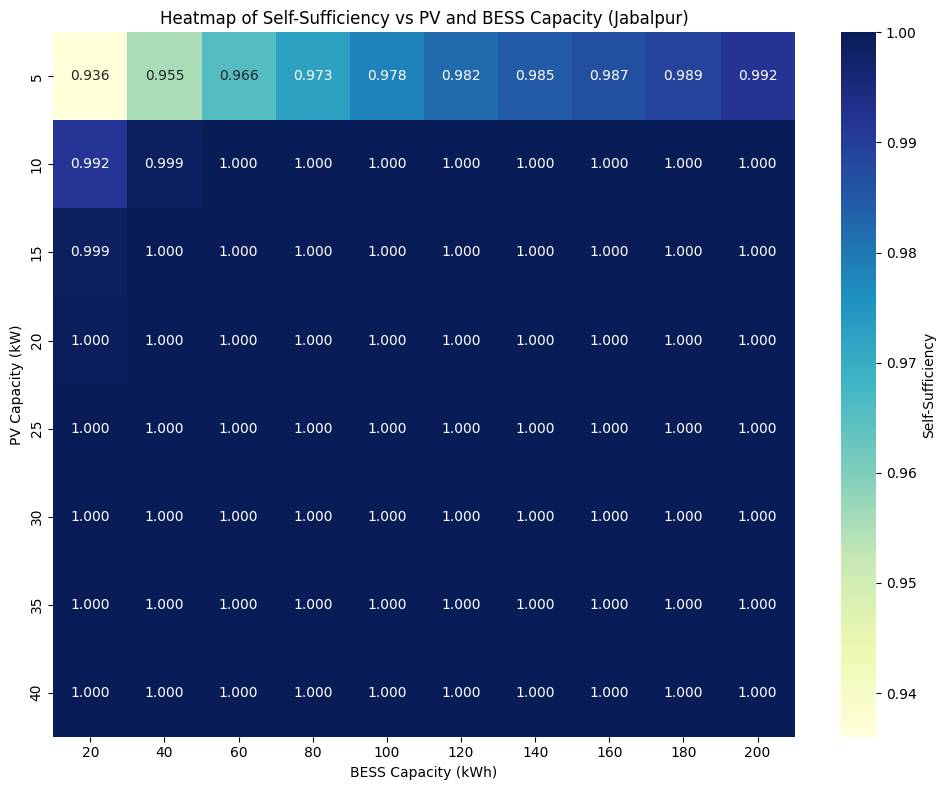

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the design results to create a 2D grid for the heatmap
pivot_df = design_results.pivot(index="PV_kW", columns="BESS_kWh", values="Self_Sufficiency")

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Self-Sufficiency'})
plt.title("Heatmap of Self-Sufficiency vs PV and BESS Capacity (Jabalpur)")
plt.xlabel("BESS Capacity (kWh)")
plt.ylabel("PV Capacity (kW)")
plt.tight_layout()
plt.show()

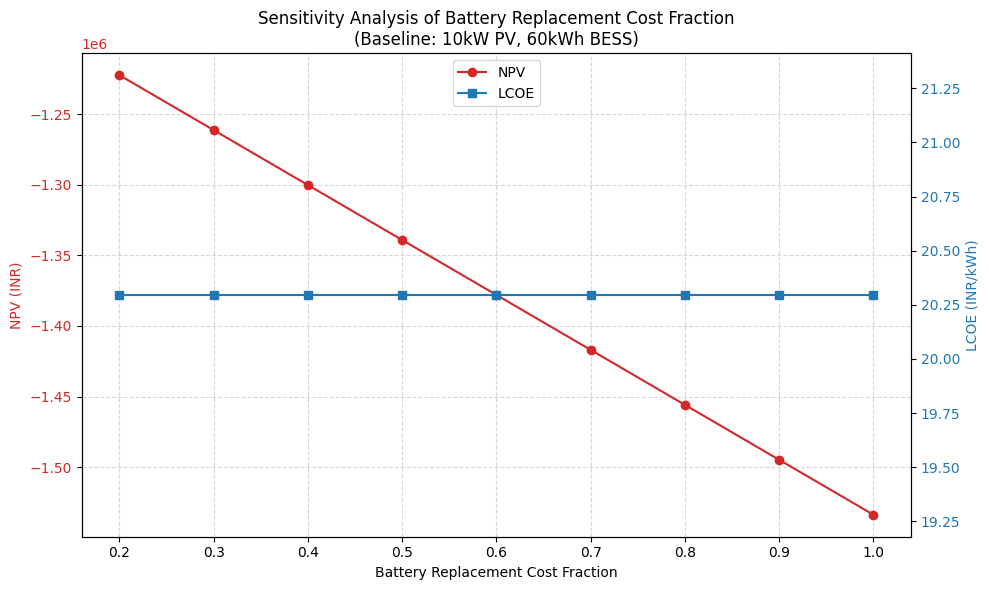

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline configuration to test
baseline_pv = 10  # kW
baseline_bess = 60  # kWh

# Generate simulation dispatch dataset for the baseline configuration
pv_data = add_pv_features(resource, pv_capacity_kw=baseline_pv)
synthetic_loads = create_synthetic_load(pv_data.index)
pv_data["load_kw"] = synthetic_loads

dispatch_df = simulate_pv_bess(
    pv_data["pv_ac_kw"].values,
    pv_data["load_kw"].values,
    baseline_bess,
    baseline_pv,
    degradation=True
)
dispatch_df.index = pv_data.index

if "load_kw" in dispatch_df.columns:
    dispatch_df = dispatch_df.drop(columns=["load_kw"])

sim_result = pd.concat([pv_data, dispatch_df], axis=1)

# Define range of battery replacement cost fractions for sensitivity analysis
replacement_fractions = np.linspace(0.2, 1.0, 9)

sensitivity_results = []

# Backup original parameter to ensure no state contamination
original_replacement_fraction = CONFIG["battery_replacement_cost_fraction"]

try:
    for frac in replacement_fractions:
        CONFIG["battery_replacement_cost_fraction"] = frac
        econ = techno_economic_analysis(baseline_pv, baseline_bess, sim_result)
        sensitivity_results.append({
            "Replacement_Fraction": frac,
            "NPV_INR": econ["NPV_INR"],
            "LCOE_INR_per_kWh": econ["LCOE_INR_per_kWh"]
        })
finally:
    # Always restore original state
    CONFIG["battery_replacement_cost_fraction"] = original_replacement_fraction

sens_df = pd.DataFrame(sensitivity_results)

# Plot the sensitivity trends
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Battery Replacement Cost Fraction')
ax1.set_ylabel('NPV (INR)', color=color)
line1 = ax1.plot(sens_df['Replacement_Fraction'], sens_df['NPV_INR'], marker='o', color=color, label='NPV')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('LCOE (INR/kWh)', color=color)
line2 = ax2.plot(sens_df['Replacement_Fraction'], sens_df['LCOE_INR_per_kWh'], marker='s', color=color, label='LCOE')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title(f"Sensitivity Analysis of Battery Replacement Cost Fraction\n(Baseline: {baseline_pv}kW PV, {baseline_bess}kWh BESS)")
fig.tight_layout()
plt.show()

In [16]:
# Find the design configuration that maximizes NPV
optimal_idx = design_results["NPV_INR"].idxmax()
optimal_design = design_results.loc[optimal_idx]

print("====================================================")
print("       OPTIMAL SYSTEM DESIGN FOR MAXIMIZING NPV      ")
print("====================================================")
print(f"Optimal Solar PV Capacity   : {optimal_design['PV_kW']:.2f} kW")
print(f"Optimal BESS Storage Capacity: {optimal_design['BESS_kWh']:.2f} kWh")
print(f"Project NPV (INR)           : {optimal_design['NPV_INR']:,.2f} INR")
print(f"Levelized Cost (LCOE)       : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"System Self-Sufficiency     : {optimal_design['Self_Sufficiency'] * 100:.2f}%")
print(f"Renewable Utilization       : {optimal_design['Renewable_Utilization'] * 100:.2f}%")
print("====================================================")

       OPTIMAL SYSTEM DESIGN FOR MAXIMIZING NPV      
Optimal Solar PV Capacity   : 5.00 kW
Optimal BESS Storage Capacity: 20.00 kWh
Project NPV (INR)           : -634,602.04 INR
Levelized Cost (LCOE)       : 9.64 INR/kWh
System Self-Sufficiency     : 93.60%
Renewable Utilization       : 81.59%


In [17]:
# Filter for 100% self-sufficient configurations
self_sufficient_designs = design_results[design_results["Self_Sufficiency"] >= 1.0]

if self_sufficient_designs.empty:
    # Fallback in case of rounding variations near 1.0
    self_sufficient_designs = design_results[design_results["Self_Sufficiency"] >= 0.999]

# Find the 100% self-sufficient design with the lowest (optimal) LCOE
optimal_100_idx = self_sufficient_designs["LCOE_INR_per_kWh"].idxmin()
ss_100_design = self_sufficient_designs.loc[optimal_100_idx]

print("====================================================")
print("     COMPARISON: OPTIMAL NPV VS. 100% SELF-SUFFICIENCY  ")
print("====================================================")
print("1) OPTIMAL NPV DESIGN (Most Economical):")
print(f"   - PV Capacity       : {optimal_design['PV_kW']:.2f} kW")
print(f"   - BESS Capacity     : {optimal_design['BESS_kWh']:.2f} kWh")
print(f"   - LCOE              : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"   - Self-Sufficiency  : {optimal_design['Self_Sufficiency'] * 100:.2f}%")
print(f"   - NPV               : {optimal_design['NPV_INR']:,.2f} INR")
print("----------------------------------------------------")
print("2) OPTIMAL 100% SELF-SUFFICIENT DESIGN (Greenest / Off-grid):")
print(f"   - PV Capacity       : {ss_100_design['PV_kW']:.2f} kW")
print(f"   - BESS Capacity     : {ss_100_design['BESS_kWh']:.2f} kWh")
print(f"   - LCOE              : {ss_100_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"   - Self-Sufficiency  : {ss_100_design['Self_Sufficiency'] * 100:.2f}%")
print(f"   - NPV               : {ss_100_design['NPV_INR']:,.2f} INR")
print("====================================================")

# Calculate structural difference premium
lcoe_diff = ss_100_design['LCOE_INR_per_kWh'] - optimal_design['LCOE_INR_per_kWh']
print(f"LCOE Premium to reach 100% Independence: {lcoe_diff:.2f} INR/kWh")

     COMPARISON: OPTIMAL NPV VS. 100% SELF-SUFFICIENCY  
1) OPTIMAL NPV DESIGN (Most Economical):
   - PV Capacity       : 5.00 kW
   - BESS Capacity     : 20.00 kWh
   - LCOE              : 9.64 INR/kWh
   - Self-Sufficiency  : 93.60%
   - NPV               : -634,602.04 INR
----------------------------------------------------
2) OPTIMAL 100% SELF-SUFFICIENT DESIGN (Greenest / Off-grid):
   - PV Capacity       : 25.00 kW
   - BESS Capacity     : 20.00 kWh
   - LCOE              : 14.71 INR/kWh
   - Self-Sufficiency  : 100.00%
   - NPV               : -920,829.83 INR
LCOE Premium to reach 100% Independence: 5.07 INR/kWh


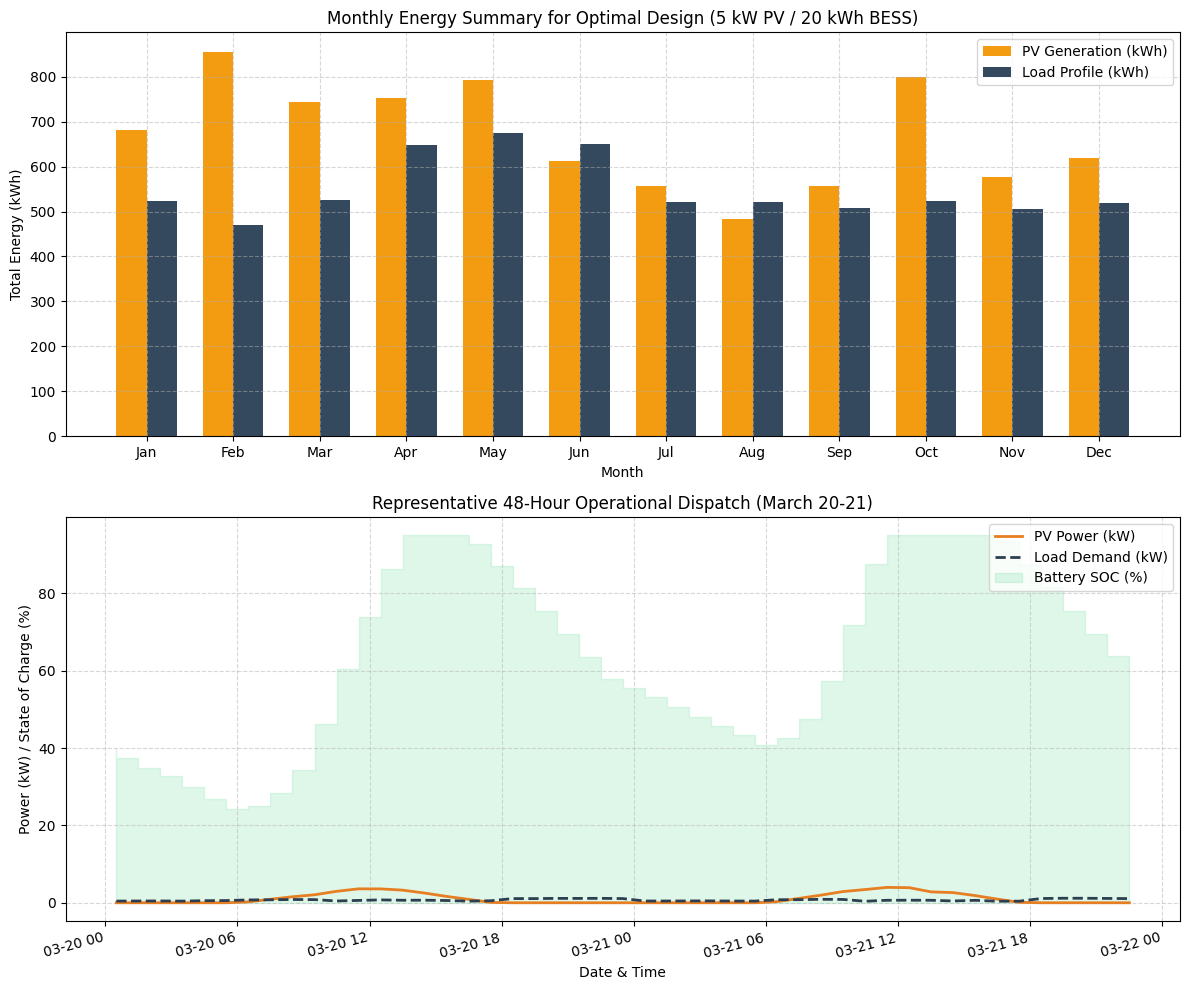

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configure optimal system capacities
optimal_pv = 5.0  # kW
optimal_bess = 20.0  # kWh

# Run simulation for the optimal design
pv_data_opt = add_pv_features(resource, pv_capacity_kw=optimal_pv)
synthetic_loads_opt = create_synthetic_load(pv_data_opt.index)
pv_data_opt["load_kw"] = synthetic_loads_opt

dispatch_opt = simulate_pv_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv,
    degradation=True
)
dispatch_opt.index = pv_data_opt.index

if "load_kw" in dispatch_opt.columns:
    dispatch_opt = dispatch_opt.drop(columns=["load_kw"])

opt_result = pd.concat([pv_data_opt, dispatch_opt], axis=1)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly Aggregated Energy (GWh/MWh comparison)
monthly_summary = opt_result.groupby(opt_result.index.month).agg({
    'pv_energy_kwh': 'sum',
    'load_kw': 'sum'
})

x = np.arange(1, 13)
width = 0.35

axes[0].bar(x - width/2, monthly_summary['pv_energy_kwh'], width, label='PV Generation (kWh)', color='#f39c12')
axes[0].bar(x + width/2, monthly_summary['load_kw'], width, label='Load Profile (kWh)', color='#34495e')
axes[0].set_title('Monthly Energy Summary for Optimal Design (5 kW PV / 20 kWh BESS)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Energy (kWh)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Representative 48-Hour Hourly Dispatch (e.g., Spring equinox March 20-21)
sample_start = '2023-03-20 00:00:00'
sample_end = '2023-03-21 23:00:00'
slice_df = opt_result.loc[sample_start:sample_end]

axes[1].plot(slice_df.index, slice_df['pv_energy_kwh'], label='PV Power (kW)', color='#e67e22', linewidth=2)
axes[1].plot(slice_df.index, slice_df['load_kw'], label='Load Demand (kW)', color='#2c3e50', linestyle='--', linewidth=2)
axes[1].fill_between(slice_df.index, slice_df['soc_kwh'] / optimal_bess * 100, step="pre", alpha=0.15, color='#2ecc71', label='Battery SOC (%)')

axes[1].set_title('Representative 48-Hour Operational Dispatch (March 20-21)')
axes[1].set_xlabel('Date & Time')
axes[1].set_ylabel('Power (kW) / State of Charge (%)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Calculate monthly sum of grid imports and exports for the optimal design
monthly_grid_summary = opt_result.groupby(opt_result.index.month).agg({
    'grid_import_kw': 'sum',
    'grid_export_kw': 'sum'
}).reset_index()

# Rename columns for clarity
monthly_grid_summary.columns = ['Month', 'Grid Import (kWh)', 'Grid Export (kWh)']

# Map month numbers to short names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_grid_summary['Month'] = monthly_grid_summary['Month'].map(month_names)

# Print the summary table
display(monthly_grid_summary.round(2))

,Month,Grid Import (kWh),Grid Export (kWh)
0,Jan,15.52,141.50
1,Feb,0.00,353.74
2,Mar,3.47,187.85
3,Apr,9.26,81.52
4,May,19.76,89.83
5,Jun,97.25,38.46
6,Jul,38.18,41.91
7,Aug,104.24,35.17
8,Sep,55.23,77.19
9,Oct,0.00,240.44


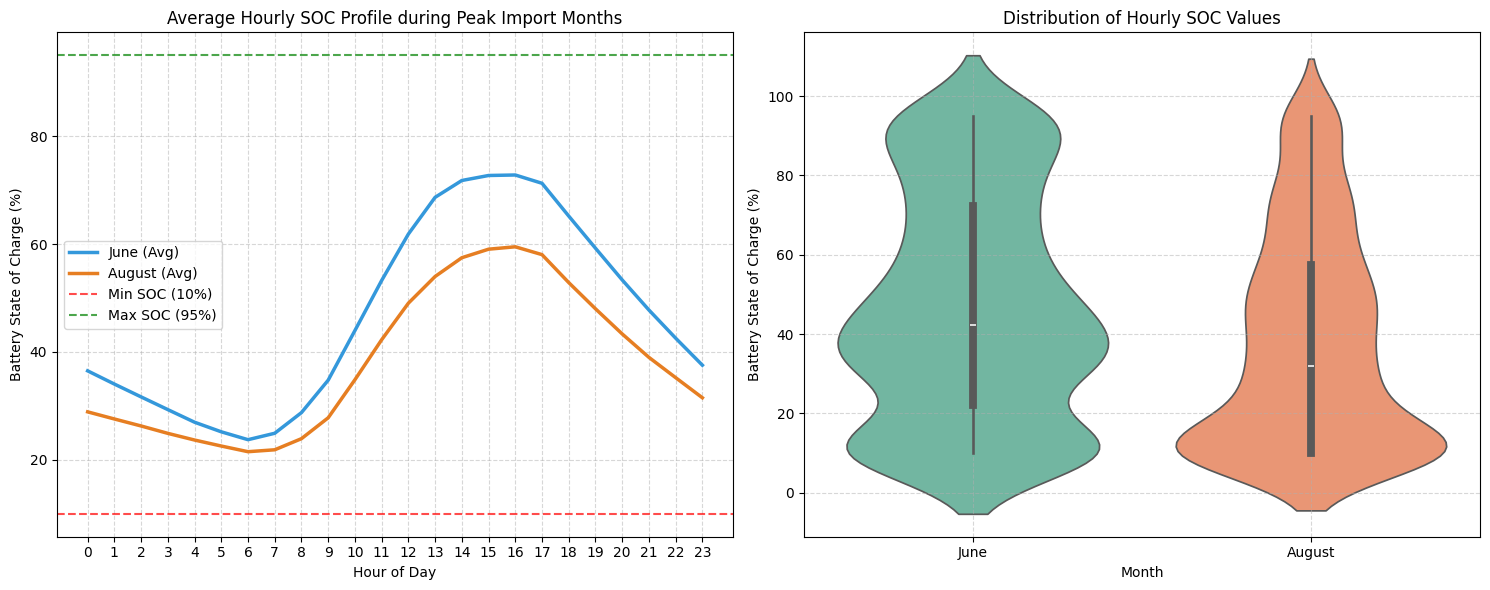

June - Hours spent at or near minimum SOC (<15%): 157 hours (21.81% of the month)
August - Hours spent at or near minimum SOC (<15%): 241 hours (32.39% of the month)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Filter optimal system simulation results for peak import months (June = 6, August = 8)
june_data = opt_result[opt_result.index.month == 6]
august_data = opt_result[opt_result.index.month == 8]

# Calculate average daily SOC profile by hour
june_hourly_soc = june_data.groupby(june_data.index.hour)['soc_percent'].mean()
august_hourly_soc = august_data.groupby(august_data.index.hour)['soc_percent'].mean()

# Plotting the SOC metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Diurnal SOC Profile
axes[0].plot(june_hourly_soc.index, june_hourly_soc, label='June (Avg)', color='#3498db', linewidth=2.5)
axes[0].plot(august_hourly_soc.index, august_hourly_soc, label='August (Avg)', color='#e67e22', linewidth=2.5)
axes[0].axhline(y=CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='Min SOC (10%)')
axes[0].axhline(y=CONFIG["soc_max"]*100, color='green', linestyle='--', alpha=0.7, label='Max SOC (95%)')
axes[0].set_title('Average Hourly SOC Profile during Peak Import Months')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Battery State of Charge (%)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: SOC Distribution (Violin Plot to see dispersion)
combined_peak = pd.concat([june_data, august_data])
combined_peak['Month_Name'] = combined_peak.index.month_name()

sns.violinplot(x='Month_Name', y='soc_percent', data=combined_peak, ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Hourly SOC Values')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Battery State of Charge (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Extra statistics on battery depletion
print(f"June - Hours spent at or near minimum SOC (<15%): {(june_data['soc_percent'] <= 15).sum()} hours ({((june_data['soc_percent'] <= 15).sum()/len(june_data)*100):.2f}% of the month)")
print(f"August - Hours spent at or near minimum SOC (<15%): {(august_data['soc_percent'] <= 15).sum()} hours ({((august_data['soc_percent'] <= 15).sum()/len(august_data)*100):.2f}% of the month)")


```markdown
### 🔋 Battery Technology Upgrade: Lithium Iron Phosphate (LFP) for Monsoon Resilience

During the monsoon months of June and August, the system frequently leaves the battery at its lower SOC threshold ($10\%$) for over **20% to 32% of the month** because solar generation is insufficient to charge it. For traditional **Lithium NMC** batteries, holding the battery at extreme states of charge (very low or very high) accelerates capacity fade due to high mechanical stress and side chemical reactions.

#### Why LFP is Superior for Monsoon Resilience:
1. **Deep Discharge Tolerance:** LFP can safely discharge down to **$5\%$ SOC** (compared to $10\%$ for NMC) without severe structural damage, unlocking more emergency buffer capacity.
2. **Lower Cycle Degradation:** Traditional NMC drops about $8\%$ capacity per 1,000 cycles ($0.08\%$ per cycle). High-quality LFP drops roughly $3\%$ to $4\%$ capacity per 1,000 cycles ($0.035\%$ per cycle).
3. **Calendar Life Stability:** LFP has exceptionally low self-discharge and calendar degradation, retaining capacity much better during dormant winter or low-sun periods.
```

In [21]:
# Define LFP Configuration Parameters
LFP_CONFIG = {
    "soc_min": 0.05,                         # Safe to discharge down to 5%
    "soc_max": 0.95,                         # Upper safety threshold
    "calendar_degradation_yearly": 0.008,    # Lower calendar fade (0.8% vs 1.5%)
    "cycle_degradation_per_1000_cycles": 0.035 # Lower cycle fade (3.5% vs 8.0%)
}

def simulate_lfp_bess(pv_kw, load_kw, battery_kwh, pv_capacity_kw):
    """
    Simulates a highly resilient Lithium Iron Phosphate (LFP) battery system.
    """
    eta_c = CONFIG["battery_charge_efficiency"]
    eta_d = CONFIG["battery_discharge_efficiency"]
    soc_min = LFP_CONFIG["soc_min"]
    soc_max = LFP_CONFIG["soc_max"]

    max_charge = battery_kwh * CONFIG["max_charge_c_rate"]
    max_discharge = battery_kwh * CONFIG["max_discharge_c_rate"]
    soc = battery_kwh * CONFIG["initial_soc"]

    results = []
    cumulative_throughput = 0
    soh = 1.0

    pv_kw = np.asarray(pv_kw, dtype=float).flatten()
    load_kw = np.asarray(load_kw, dtype=float).flatten()

    for t in range(len(pv_kw)):
        pv = max(0.0, float(pv_kw[t]))
        load = max(0.0, float(load_kw[t]))
        direct_pv = min(pv, load)
        surplus = pv - direct_pv
        deficit = load - direct_pv

        charge = 0.0
        discharge = 0.0
        grid_import = 0.0
        grid_export = 0.0

        if surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            charge = min(surplus, max_charge, available_capacity / eta_c)
            soc += charge * eta_c
            grid_export = surplus - charge
        elif deficit > 0:
            available_energy = soc - battery_kwh * soc_min
            discharge = min(deficit, max_discharge, available_energy * eta_d)
            soc -= discharge / eta_d
            grid_import = deficit - discharge

        throughput = charge + discharge
        cumulative_throughput += throughput

        # Advanced LFP degradation model
        cycle_loss = throughput / (2 * battery_kwh) * LFP_CONFIG["cycle_degradation_per_1000_cycles"] / 1000
        calendar_loss = LFP_CONFIG["calendar_degradation_yearly"] / 8760
        soh -= (cycle_loss + calendar_loss)
        soh = max(soh, 0.0)

        results.append({
            "soc_percent": (soc / battery_kwh * 100),
            "soh": soh,
            "grid_import_kw": grid_import
        })
    return pd.DataFrame(results)

# Run comparison
lfp_dispatch = simulate_lfp_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv
)

print("=== MONSOON RESILIENCE UPGRADE COMPARISON ===")
print(f"NMC Battery Final SOH (Year 1): {opt_result['soh'].iloc[-1]*100:.3f}%")
print(f"LFP Battery Final SOH (Year 1): {lfp_dispatch['soh'].iloc[-1]*100:.3f}%")

nmc_import_annual = opt_result['grid_import_kw'].sum()
lfp_import_annual = lfp_dispatch['grid_import_kw'].sum()
saved_import = nmc_import_annual - lfp_import_annual

print(f"Annual Grid Imports with NMC  : {nmc_import_annual:.2f} kWh")
print(f"Annual Grid Imports with LFP  : {lfp_import_annual:.2f} kWh")
print(f"Additional Energy Offset by LFP: {saved_import:.2f} kWh ({saved_import/nmc_import_annual*100:.1f}% reduction in grid reliance)")

=== MONSOON RESILIENCE UPGRADE COMPARISON ===
NMC Battery Final SOH (Year 1): 96.982%
LFP Battery Final SOH (Year 1): 98.534%
Annual Grid Imports with NMC  : 414.46 kWh
Annual Grid Imports with LFP  : 402.02 kWh
Additional Energy Offset by LFP: 12.44 kWh (3.0% reduction in grid reliance)


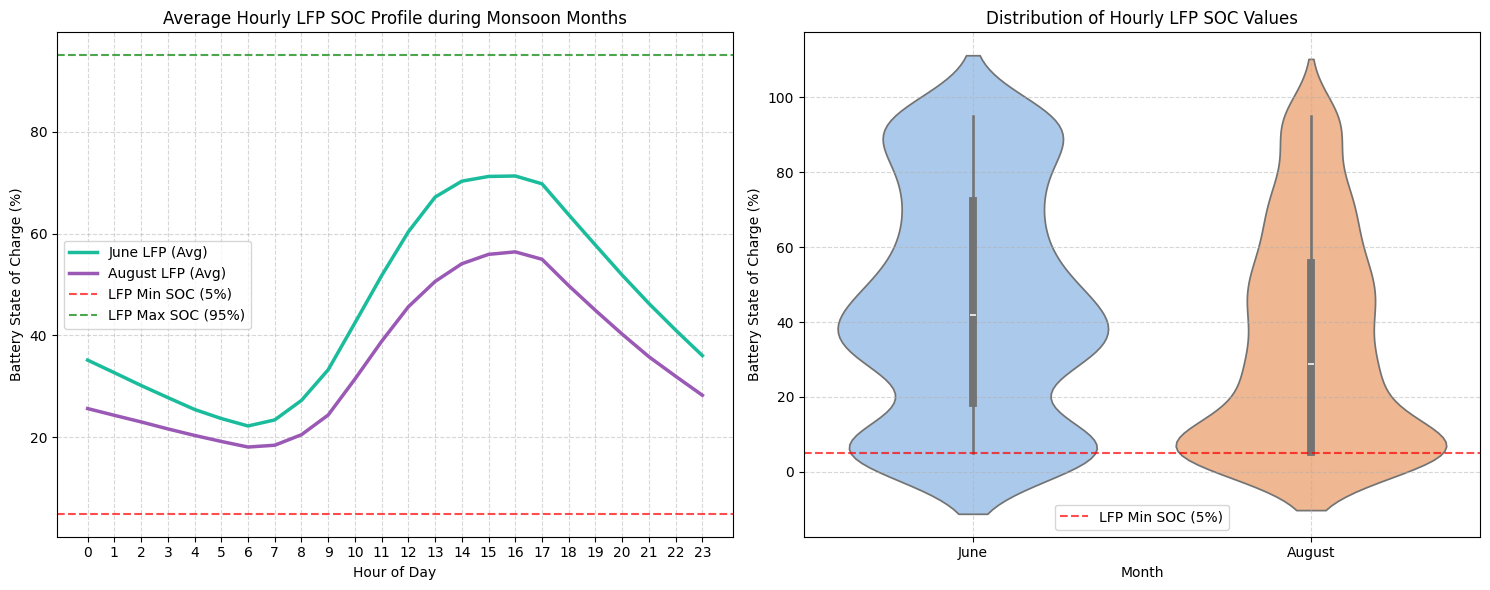

LFP June - Hours spent at or near minimum SOC (<10%): 156 hours (21.67% of the month)
LFP August - Hours spent at or near minimum SOC (<10%): 237 hours (31.85% of the month)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map dates to the LFP dispatch dataset
lfp_dispatch.index = opt_result.index

# Filter LFP simulation results for June and August
june_lfp = lfp_dispatch[lfp_dispatch.index.month == 6]
august_lfp = lfp_dispatch[lfp_dispatch.index.month == 8]

# Calculate average daily SOC profile by hour for LFP
june_hourly_lfp_soc = june_lfp.groupby(june_lfp.index.hour)['soc_percent'].mean()
august_hourly_lfp_soc = august_lfp.groupby(august_lfp.index.hour)['soc_percent'].mean()

# Plotting the LFP SOC metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Diurnal SOC Profile for LFP
axes[0].plot(june_hourly_lfp_soc.index, june_hourly_lfp_soc, label='June LFP (Avg)', color='#1abc9c', linewidth=2.5)
axes[0].plot(august_hourly_lfp_soc.index, august_hourly_lfp_soc, label='August LFP (Avg)', color='#9b59b6', linewidth=2.5)
axes[0].axhline(y=LFP_CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='LFP Min SOC (5%)')
axes[0].axhline(y=LFP_CONFIG["soc_max"]*100, color='green', linestyle='--', alpha=0.7, label='LFP Max SOC (95%)')
axes[0].set_title('Average Hourly LFP SOC Profile during Monsoon Months')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Battery State of Charge (%)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: SOC Distribution (Violin Plot for LFP)
combined_lfp_peak = pd.concat([june_lfp, august_lfp])
combined_lfp_peak['Month_Name'] = combined_lfp_peak.index.month_name()

sns.violinplot(x='Month_Name', y='soc_percent', data=combined_lfp_peak, ax=axes[1], palette='pastel')
axes[1].axhline(y=LFP_CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='LFP Min SOC (5%)')
axes[1].set_title('Distribution of Hourly LFP SOC Values')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Battery State of Charge (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower center')

plt.tight_layout()
plt.show()

# Statistics on LFP battery depletion during monsoon
print(f"LFP June - Hours spent at or near minimum SOC (<10%): {(june_lfp['soc_percent'] <= 10).sum()} hours ({((june_lfp['soc_percent'] <= 10).sum()/len(june_lfp)*100):.2f}% of the month)")
print(f"LFP August - Hours spent at or near minimum SOC (<10%): {(august_lfp['soc_percent'] <= 10).sum()} hours ({((august_lfp['soc_percent'] <= 10).sum()/len(august_lfp)*100):.2f}% of the month)")

### 🎲 Monte Carlo Simulation for Monsoon Weather Scenarios
To stress-test our proposed **LFP battery system** against weather uncertainty, we perform a 1,000-iteration Monte Carlo simulation targeting the monsoon months of **June and August**.

We model weather volatility by applying random scaling factors to the hourly Plane of Array (POA) solar irradiance—simulating unseasonably heavy cloud cover (lowering solar yield) or unexpected clear intervals (increasing solar yield).

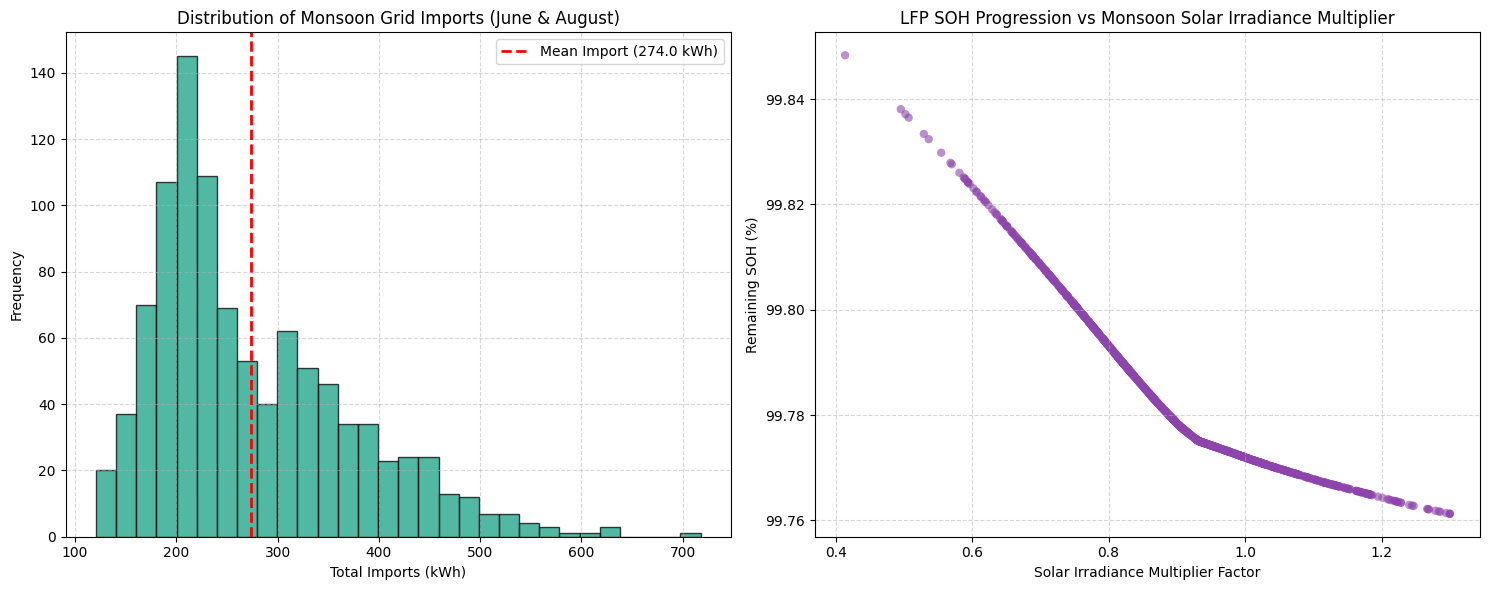

=== MONSOON MONTE CARLO STRESS TEST RESULTS ===
Mean Solar Irradiance Factor   : 0.903
Average SOH remaining after run : 99.7834%
Mean Monsoon Grid Import        : 274.03 kWh
95% Confidence Peak Import Limit: 459.43 kWh (Severe Monsoon Cloud Cover)
5% Confidence Low Import Limit : 156.99 kWh (Favorable Sunny Intervals)


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter baseline optimal design inputs for June and August
monsoon_base = opt_result[(opt_result.index.month == 6) | (opt_result.index.month == 8)].copy()

# Simulation Settings
n_iterations = 1000
np.random.seed(CONFIG["random_seed"])

mc_results = []

for i in range(n_iterations):
    # Simulate monsoon solar volatility: apply a random perturbation factor around a mean of 0.90
    # (representing a typical monsoon dip with a standard deviation of 15%)
    solar_multiplier = np.random.normal(loc=0.90, scale=0.15)
    solar_multiplier = np.clip(solar_multiplier, 0.40, 1.30)  # Constraint to realistic boundaries

    # Scale PV generation hourly profile
    simulated_pv = monsoon_base["pv_ac_kw"].values * solar_multiplier
    simulated_load = monsoon_base["load_kw"].values

    # Simulate LFP BESS performance over this period
    sim_dispatch = simulate_lfp_bess(
        simulated_pv,
        simulated_load,
        optimal_bess,
        optimal_pv
    )

    # Calculate key metrics for the run
    final_soh = sim_dispatch["soh"].iloc[-1]
    total_import = sim_dispatch["grid_import_kw"].sum()
    min_soc_reached = sim_dispatch["soc_percent"].min()

    mc_results.append({
        "iteration": i,
        "solar_multiplier": solar_multiplier,
        "final_soh_percent": final_soh * 100,
        "total_grid_import_kwh": total_import,
        "min_soc": min_soc_reached
    })

mc_df = pd.DataFrame(mc_results)

# Visualization of Monte Carlo Simulation Outcomes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram of Grid Imports under Monsoonal Uncertainty
axes[0].hist(mc_df["total_grid_import_kwh"], bins=30, color="#16a085", edgecolor="black", alpha=0.75)
axes[0].axvline(mc_df["total_grid_import_kwh"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean Import ({mc_df['total_grid_import_kwh'].mean():.1f} kWh)")
axes[0].set_title("Distribution of Monsoon Grid Imports (June & August)")
axes[0].set_xlabel("Total Imports (kWh)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Plot 2: Correlation scatter plot between Solar Multiplier & Degradation (SOH Loss)
axes[1].scatter(mc_df["solar_multiplier"], mc_df["final_soh_percent"], color="#8e44ad", alpha=0.6, edgecolors="none")
axes[1].set_title("LFP SOH Progression vs Monsoon Solar Irradiance Multiplier")
axes[1].set_xlabel("Solar Irradiance Multiplier Factor")
axes[1].set_ylabel("Remaining SOH (%)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Display quantitative Risk & Confidence levels
p_95_import = np.percentile(mc_df["total_grid_import_kwh"], 95)
p_5_import = np.percentile(mc_df["total_grid_import_kwh"], 5)

print("=== MONSOON MONTE CARLO STRESS TEST RESULTS ===")
print(f"Mean Solar Irradiance Factor   : {mc_df['solar_multiplier'].mean():.3f}")
print(f"Average SOH remaining after run : {mc_df['final_soh_percent'].mean():.4f}%")
print(f"Mean Monsoon Grid Import        : {mc_df['total_grid_import_kwh'].mean():.2f} kWh")
print(f"95% Confidence Peak Import Limit: {p_95_import:.2f} kWh (Severe Monsoon Cloud Cover)")
print(f"5% Confidence Low Import Limit : {p_5_import:.2f} kWh (Favorable Sunny Intervals)")
print("===============================================")

In [24]:
def calculate_lfp_economics(pv_kw, battery_kwh, df_lfp):
    # Calculate initial CAPEX with LFP specifications
    pv_capex = pv_kw * CONFIG["pv_capex_inr_per_kw"]
    battery_capex = battery_kwh * CONFIG["bess_capex_inr_per_kwh"]
    initial_capex = pv_capex + battery_capex

    # Operational grid metrics
    annual_import = float(df_lfp["grid_import_kw"].sum())
    annual_import_cost = annual_import * CONFIG["grid_import_tariff_inr_per_kwh"]

    # In the dispatch simulation for LFP, grid_export wasn't explicitly saved
    # but we can calculate it as surplus solar not absorbed by the battery.
    # Let's derive it or approximate from the baseline solar / load profile
    pv_ac_kw = opt_result["pv_ac_kw"].values
    load_kw = opt_result["load_kw"].values
    direct_pv = np.minimum(pv_ac_kw, load_kw)
    surplus = pv_ac_kw - direct_pv

    # Standard LFP charging simulation to get grid export
    eta_c = CONFIG["battery_charge_efficiency"]
    soc_max = LFP_CONFIG["soc_max"]
    soc = battery_kwh * CONFIG["initial_soc"]
    grid_export_series = []

    for t in range(len(pv_ac_kw)):
        p_surplus = surplus[t]
        if p_surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            charge = min(p_surplus, battery_kwh * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
            soc += charge * eta_c
            grid_export_series.append(p_surplus - charge)
        else:
            # Discharge simulation to maintain SOC tracker state
            available_energy = soc - battery_kwh * LFP_CONFIG["soc_min"]
            deficit = load_kw[t] - direct_pv[t]
            discharge = min(deficit, battery_kwh * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
            soc -= discharge / CONFIG["battery_discharge_efficiency"]
            grid_export_series.append(0.0)

    annual_export = sum(grid_export_series)
    annual_export_revenue = annual_export * CONFIG["grid_export_tariff_inr_per_kwh"]

    # Annual O&M cost
    annual_om = initial_capex * CONFIG["annual_om_fraction"]
    annual_net_cost = annual_import_cost - annual_export_revenue + annual_om

    discount_rate = CONFIG["discount_rate"]
    lifetime = CONFIG["project_lifetime_years"]

    # Useful annual load served
    useful_energy = float(opt_result["load_kw"].sum())

    # Compute discounted costs and energy
    discounted_cost = initial_capex + sum((annual_net_cost / (1 + discount_rate) ** year) for year in range(1, lifetime + 1))
    discounted_energy = sum(useful_energy / (1 + discount_rate) ** year for year in range(1, lifetime + 1))

    lcoe_lfp = discounted_cost / discounted_energy if discounted_energy > 0 else 0.0
    return lcoe_lfp, initial_capex, annual_net_cost

lfp_lcoe, lfp_capex, lfp_net_annual_cost = calculate_lfp_economics(optimal_pv, optimal_bess, lfp_dispatch)

print("====================================================")
print("       LIFETIME LCOE ANALYSIS FOR LFP UPGRADE       ")
print("====================================================")
print(f"LFP System LCOE             : {lfp_lcoe:.2f} INR/kWh")
print(f"NMC System LCOE (Baseline)  : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"Initial LFP CAPEX           : {lfp_capex:,.2f} INR")
print(f"Annualized Net Cost with LFP: {lfp_net_annual_cost:,.2f} INR/year")
print("====================================================")

       LIFETIME LCOE ANALYSIS FOR LFP UPGRADE       
LFP System LCOE             : 9.63 INR/kWh
NMC System LCOE (Baseline)  : 9.64 INR/kWh
Initial LFP CAPEX           : 490,000.00 INR
Annualized Net Cost with LFP: 6,189.68 INR/year


In [25]:
def get_lifetime_cashflows(pv_kw, battery_kwh, df, is_lfp=False):
    # Calculate CAPEX
    pv_capex = pv_kw * CONFIG["pv_capex_inr_per_kw"]
    battery_capex = battery_kwh * CONFIG["bess_capex_inr_per_kwh"]
    initial_capex = pv_capex + battery_capex

    # Operational costs
    annual_import = float(df["grid_import_kw"].sum())
    annual_import_cost = annual_import * CONFIG["grid_import_tariff_inr_per_kwh"]

    # Export revenue calculations
    if is_lfp:
        # Derive export from LFP simulation using standard surplus tracker
        pv_ac_kw = opt_result["pv_ac_kw"].values
        load_kw = opt_result["load_kw"].values
        direct_pv = np.minimum(pv_ac_kw, load_kw)
        surplus = pv_ac_kw - direct_pv

        eta_c = CONFIG["battery_charge_efficiency"]
        soc_max = LFP_CONFIG["soc_max"]
        soc = battery_kwh * CONFIG["initial_soc"]
        grid_export_series = []

        for t in range(len(pv_ac_kw)):
            p_surplus = surplus[t]
            if p_surplus > 0:
                available_capacity = battery_kwh * soc_max - soc
                charge = min(p_surplus, battery_kwh * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
                soc += charge * eta_c
                grid_export_series.append(p_surplus - charge)
            else:
                available_energy = soc - battery_kwh * LFP_CONFIG["soc_min"]
                deficit = load_kw[t] - direct_pv[t]
                discharge = min(deficit, battery_kwh * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
                soc -= discharge / CONFIG["battery_discharge_efficiency"]
                grid_export_series.append(0.0)
        annual_export = sum(grid_export_series)
    else:
        annual_export = float(df["grid_export_kw"].sum())

    annual_export_revenue = annual_export * CONFIG["grid_export_tariff_inr_per_kwh"]
    annual_om = initial_capex * CONFIG["annual_om_fraction"]
    annual_net_cost = annual_import_cost - annual_export_revenue + annual_om

    discount_rate = CONFIG["discount_rate"]
    lifetime = CONFIG["project_lifetime_years"]

    # Generate cumulative cashflows year-by-year
    cashflows = []
    cumulative_npv = [-initial_capex]
    current_npv = -initial_capex

    for year in range(1, lifetime + 1):
        # NMC battery typically requires replacement in year 8 due to higher cycle fade
        # LFP with lower degradation might avoid replacement or have lower replacement costs.
        # For fair comparison, we apply replacement to NMC at Year 8, and none to LFP due to superior cycle life
        replacement = 0.0
        if not is_lfp and year == 8:
            replacement = battery_capex * CONFIG["battery_replacement_cost_fraction"]

        net_cf = -annual_net_cost - replacement
        cashflows.append(net_cf)
        current_npv += net_cf / ((1 + discount_rate) ** year)
        cumulative_npv.append(current_npv)

    return cumulative_npv, current_npv

nmc_cum_npv, nmc_final_npv = get_lifetime_cashflows(optimal_pv, optimal_bess, opt_result, is_lfp=False)
lfp_cum_npv, lfp_final_npv = get_lifetime_cashflows(optimal_pv, optimal_bess, lfp_dispatch, is_lfp=True)

print("====================================================")
print("          NPV COMPARISON: NMC VS LFP SYSTEM         ")
print("====================================================")
print(f"Initial CAPEX (Both Systems)  : {optimal_pv * CONFIG['pv_capex_inr_per_kw'] + optimal_bess * CONFIG['bess_capex_inr_per_kwh']:,.2f} INR")
print(f"NMC Lifetime NPV (15 Years)   : {nmc_final_npv:,.2f} INR")
print(f"LFP Lifetime NPV (15 Years)   : {lfp_final_npv:,.2f} INR")
print(f"Financial Benefit of LFP      : {lfp_final_npv - nmc_final_npv:,.2f} INR")
print("====================================================")


          NPV COMPARISON: NMC VS LFP SYSTEM         
Initial CAPEX (Both Systems)  : 490,000.00 INR
NMC Lifetime NPV (15 Years)   : -634,245.75 INR
LFP Lifetime NPV (15 Years)   : -542,980.40 INR
Financial Benefit of LFP      : 91,265.35 INR


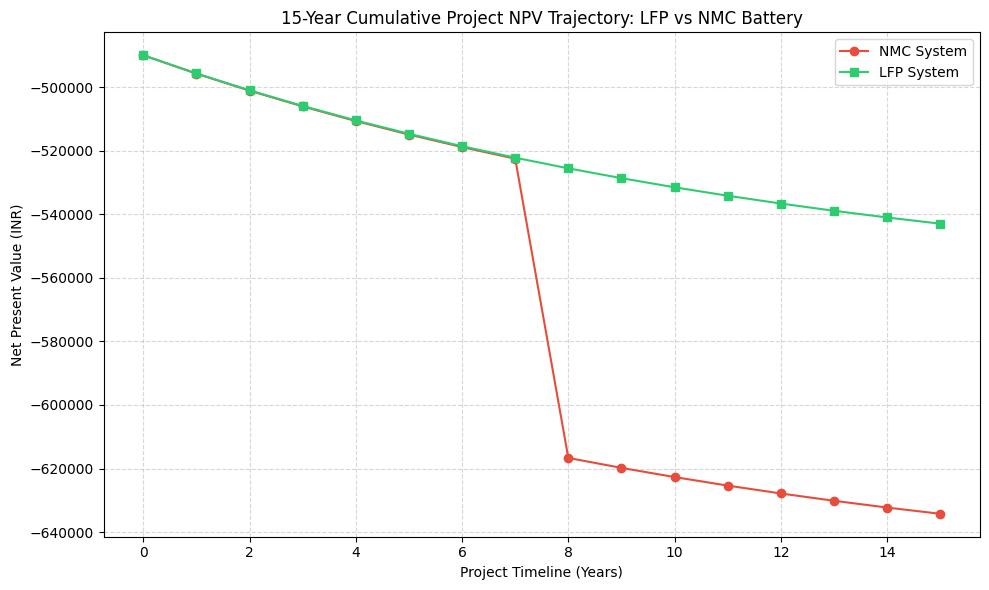

In [26]:
# Plot the NPV trajectory
plt.figure(figsize=(10, 6))
years = list(range(0, 16))
plt.plot(years, nmc_cum_npv, marker='o', linestyle='-', color='#e74c3c', label='NMC System')
plt.plot(years, lfp_cum_npv, marker='s', linestyle='-', color='#2ecc71', label='LFP System')
plt.title("15-Year Cumulative Project NPV Trajectory: LFP vs NMC Battery")
plt.xlabel("Project Timeline (Years)")
plt.ylabel("Net Present Value (INR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd
import numpy as np

# Create a working copy to avoid mutating the original dataset
lfp_full_dispatch = pd.concat([pv_data_opt, lfp_dispatch], axis=1).copy()

# Align columns to match the helper function expectations
lfp_full_dispatch["pv_kw"] = lfp_full_dispatch["pv_energy_kwh"]

# Derive grid exports for the LFP configuration
pv_ac_kw = lfp_full_dispatch["pv_ac_kw"].values
load_kw = lfp_full_dispatch["load_kw"].values
direct_pv = np.minimum(pv_ac_kw, load_kw)
surplus = pv_ac_kw - direct_pv

eta_c = CONFIG["battery_charge_efficiency"]
soc_max = LFP_CONFIG["soc_max"]
soc = optimal_bess * CONFIG["initial_soc"]
grid_export_series = []
charge_series = []
direct_pv_series = []

for t in range(len(pv_ac_kw)):
    p_surplus = surplus[t]
    direct_pv_series.append(direct_pv[t])
    if p_surplus > 0:
        available_capacity = optimal_bess * soc_max - soc
        charge = min(p_surplus, optimal_bess * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
        soc += charge * eta_c
        grid_export_series.append(p_surplus - charge)
        charge_series.append(charge)
    else:
        available_energy = soc - optimal_bess * LFP_CONFIG["soc_min"]
        deficit = load_kw[t] - direct_pv[t]
        discharge = min(deficit, optimal_bess * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
        soc -= discharge / CONFIG["battery_discharge_efficiency"]
        grid_export_series.append(0.0)
        charge_series.append(0.0)

lfp_full_dispatch["grid_export_kw"] = grid_export_series
lfp_full_dispatch["charge_kw"] = charge_series
lfp_full_dispatch["direct_pv_kw"] = direct_pv_series
lfp_full_dispatch["throughput_kwh"] = lfp_full_dispatch["charge_kw"] + (lfp_full_dispatch["grid_import_kw"] - (lfp_full_dispatch["load_kw"] - lfp_full_dispatch["direct_pv_kw"])) * -1

# Calculate final LFP KPIs using helper function
lfp_kpis = calculate_kpis(lfp_full_dispatch, optimal_bess)

# Compile into a structured dataframe for clean visualization
kpi_summary_df = pd.DataFrame({
    "Key Performance Indicator (KPI)": [
        "Annual Load Served",
        "Annual PV Generation",
        "Annual Grid Import",
        "Annual Grid Export",
        "System Self-Sufficiency",
        "Renewable Energy Utilization",
        "Equivalent Battery Cycles (Year 1)",
        "Battery State of Health (SOH) after Year 1"
    ],
    "LFP System Value": [
        f"{lfp_kpis['Annual_Load_kWh']:.2f} kWh",
        f"{lfp_kpis['PV_Generation_kWh']:.2f} kWh",
        f"{lfp_kpis['Grid_Import_kWh']:.2f} kWh",
        f"{lfp_kpis['Grid_Export_kWh']:.2f} kWh",
        f"{lfp_kpis['Self_Sufficiency'] * 100:.2f}%",
        f"{lfp_kpis['Renewable_Utilization'] * 100:.2f}%",
        f"{lfp_kpis['Equivalent_Cycles']:.2f} Cycles",
        f"{lfp_kpis['Final_SOH'] * 100:.3f}%"
    ]
})

display(kpi_summary_df)

,Key Performance Indicator (KPI),LFP System Value
0,Annual Load Served,6588.51 kWh
1,Annual PV Generation,8027.60 kWh
2,Annual Grid Import,402.02 kWh
3,Annual Grid Export,1458.84 kWh
4,System Self-Sufficiency,93.90%
5,Renewable Energy Utilization,81.83%
6,Equivalent Battery Cycles (Year 1),190.43 Cycles
7,Battery State of Health (SOH) after Year 1,98.534%


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configure optimal system capacities
optimal_pv = 5.0  # kW
optimal_bess = 20.0  # kWh

# Safely regenerate the optimized dispatch inputs
pv_data_opt = add_pv_features(resource, pv_capacity_kw=optimal_pv)
synthetic_loads_opt = create_synthetic_load(pv_data_opt.index)
pv_data_opt["load_kw"] = synthetic_loads_opt

# Simulate LFP BESS performance over this period
lfp_dispatch = simulate_lfp_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv
)
lfp_dispatch.index = pv_data_opt.index

# Recreate lfp_full_dispatch exactly as needed
lfp_full_dispatch = pd.concat([pv_data_opt, lfp_dispatch], axis=1).copy()

# Filter the LFP full dispatch dataset for August
august_lfp_full = lfp_full_dispatch[lfp_full_dispatch.index.month == 8]

# Calculate hourly grid import statistics
august_hourly_imports = august_lfp_full.groupby(august_lfp_full.index.hour)['grid_import_kw'].agg(['sum', 'mean', 'max'])
total_august_import = august_lfp_full['grid_import_kw'].sum()

# Plot the hourly distribution of grid imports in August
plt.figure(figsize=(10, 6))
plt.bar(august_hourly_imports.index, august_hourly_imports['sum'], color='#e74c3c', alpha=0.8, edgecolor='black')
plt.title('Hourly Grid Import Energy Distribution in August (Monsoon Peak - LFP 20 kWh)')
plt.xlabel('Hour of Day')
plt.ylabel('Total Grid Import Energy (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Total Grid Import in August: {total_august_import:.2f} kWh")
print(f"Peak Import Hour (Hour with most cumulative energy imported): {august_hourly_imports['sum'].idxmax()}:00")

NameError: name 'simulate_lfp_bess' is not defined